<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week9_1_CNN%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<딥러닝 파이토치 교과서>
p.179-200

##5장 합성곱신경망
###5.2 CNN 맛보기

- fashion_mnist 데이터셋: 작은 이미지 모음, 28*28 픽셀의 이미지 7만개
  - 훈련데이터: 0~255사이 값 갖는 28*28 넘파이 배열
  - 정답데이터: 0~9사이 값 배열, 이미지 클래스 나타냄
```
o : T-Shirt
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle Boot
```

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [16]:
# cpu, gpu 장치확인
device= torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

- GPU 사용
```
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model= Net()
model.to(device)

# 다수의 GPU사용한다면 nn.DataParallel 이용

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu)
model=Net()
if torch.cuda.device_count() >1:
    model= nn.DataParallel(net)
model.to(device)
```

In [17]:
# fasion_mnist 데이터셋 내려받기
train_dataset= torchvision.datasets.FashionMNIST('/content/drive/MyDrive/ESSA', download=True,
                                                 transform= transforms.Compose([transforms.ToTensor()]))
test_dataset= torchvision.datasets.FashionMNIST('/content/drive/MyDrive/ESSA', download=True,
                                                train= False, transform = transforms.Compose([transforms.ToTensor()]))


> torchvision.datasets -> torch.utils.data.Dataset의 하위 클래스로 다양한 데이터셋 포함함
- 파라미터
  - 내려받을 위치 지정
  - download=True면 해당 데이터셋있는지 확인하고 내려받음
  - transform : 이미지를 텐서(0~1)로 변경

In [18]:
# 데이터를 데이터로더에 전달
train_loader= torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader= torch.utils.data.DataLoader(test_dataset, batch_size=100)

> torch.utils.data.DataLoader() -> 원하는 크기의 배치 단위로 데이터 불러오거나 순서 무작위로 섞이도록 함

파라미터
- 첫번째 : 데이터 불러올 데이터셋 지정
- batch_size: 데이터를 배치로 묶음

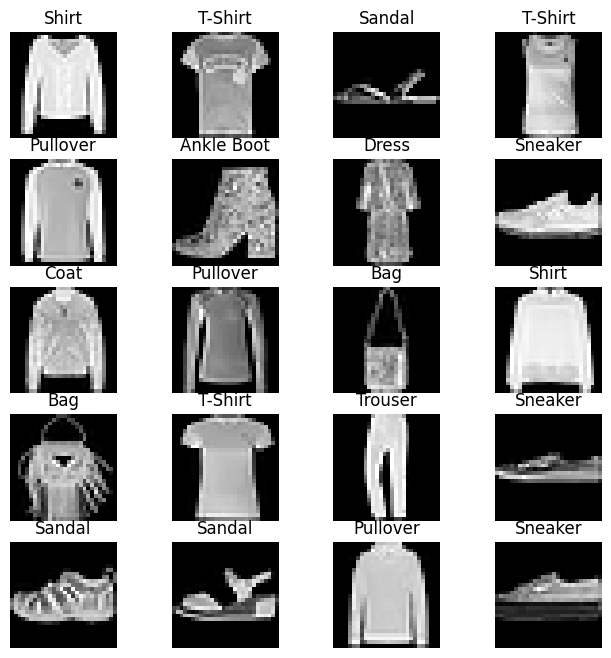

In [19]:
# 분류에 사용될 클래스 정의
# 열 개의 클래스
labels_map= {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}


fig= plt.figure(figsize=(8,8)); # inch단위
columns=4;
rows=5;
for i in range(1, columns*rows +1):
    img_xy= np.random.randint(len(train_dataset)); #1

    # 데이터셋이 (이미지, 정답)으로 이루어져있어 이미지만 가져옴
    # 이미지의 (채널, 가로, 세로) 3차원형태에서 평면 데이터를 추출함
    img= train_dataset[img_xy][0][0,:,:]  #2
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()




1. np.random.randint() : 이산형 분포를 갖는 데이터에서 무작위 표본 추출
- 0~train_dataset 길이 사이 값 중 랜덤 숫자 하나 생성
```
np.random.randint(10)
np.random.randint(1,10)

np.random.rand(8) -> 0~1 사이 표준정규분포 난수를 행렬로 (1*8) 출력
np.random.rand(4,2)

np.random.randn(8) -> 평균 0, 표편 1인 가우시안 분포 난수를 행렬(1*8)로 출력
```

2. train_dataset을 이용한 3차원 배열 생성
```
examp= np.arange(0,500,3)
examp.resize(3,5,5) -> 5*5 행렬 3개 만들어짐
```


In [20]:
# 심층신경망 모델 생성해서 비교해보자 -> ConvNet 적용안된 네트워크

class FashionDNN(nn.Module):
    #1
    def __init__(self):
        super(FashionDNN, self).__init__()

        #2
        self.fc1= nn.Linear(in_features=784, out_features=256)
        #3
        self.drop= nn.Dropout(0.25)
        self.fc2= nn.Linear(in_features=256, out_features=128)
        self.fc3= nn.Linear(in_features=128, out_features=10)

    #4
    def forward(self, input_data):
        #5
        out= input_data.view(-1, 784)
        #6
        out= F.relu(self.fc1(out))
        out= self.drop(out)
        out=F.relu(self.fc2(out))
        out= self.fc3(out)
        return out

**1. class 형태의 모델은 항상 torch.nn.Module 상속받음**
- __init__(): 객체가 갖는 속성 값 초기화, 객체 생성될 때 자동으로 호출됨
- super(FasionDNN, self).__init__() -> nn.Module클래스 상속받는다는 의미

> 객체 지향 프로그램은 프로그래밍에서 필요한 데이터를 추상화하여 속성, 행동, 동작, 특징 등을 객체로 만들고 그 객체들이 서로 유기적으로 동작하도록 하는 프로그래밍 방법, 재사용성 가짐

> 객체 : 메모리를 할당받아 프로그램에서 사용되는 모든 데이터, 변수 함수 등

> 객체명= 클래스명()

클래스와 함수
- 함수 - 프로그램 코드의 일부를 재사용하기 위해서는 해당 함수뿐만 아니라 데이터가 저장되는 변수까지도 한번에 관리해야함 -> 이것이 클래스
```
class Calc:
    def __init__(self):
        self.result=0

    def add(self, num1, num2):
        self.result= num1+num2
        return self.result
    
obj1= Calc()
obj2= Calc()

print(obj1.add(1,2))
print(obj1.add(2,3))

print(obj2.add(2,2))
print(obj2.add(2,3))
```

**2. nn: 딥러닝 모델 구성에 필요한 모듈이 모여있는 패키지**
- Linear는 단순 선형회귀 모델 만들때 사용
- 파라미터
  - 입출력 크기
  - forward() 부분에는 입력 크기만 넘겨줌, forward() 연산 결과가 출력크기가 됨

**3. torch.nn.Dropout(p)**
: p만큼의 비율로 텐서 값 0 되며 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해짐

**4. forward() : H(x) 식에 입력 x로부터 예측된 y얻는것**

**5. view: 텐서 크기 변경**

**6. 활성화 함수 지정**
- F.relu(): forward() 함수에서 정의
- nn.ReLU(): __init__() 함수에서 정의
```
## nn 사용하는 코드
import torch.nn as nn

inputs= torch.randn(64,3,244,244)

# out_channels=64 로 지정해서 필터 64개 사용
conv= nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
outputs= conv(inputs)
layer= nn.Conv2d(1,1,3)

## nn.functional 사용
import torch.nn.functional as F

inputs= torch.randn(64,3,244,244)
weight= torch.randn(64,3,3,3)
bias= torch.randn(64)
outputs= F.conv2d(inputs, weight, bias, padding=1)
```
- nn.Conv2d 에서 입출력 채널을 사용했다면 functional.conv2d는 입력, 가중치 자체를 넣어줌

In [21]:
# 심층 신경망에서 필요한 파라미터 정의
learning_rate= 0.001;
model= FashionDNN()
model.to(device)

criterion= nn.CrossEntropyLoss();
optimizer= torch.optim.Adam(model.parameters(), lr= learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


- 옵티마이저를 위한 경사하강법은 Adam사용

In [22]:
# 모델학습
num_epochs= 5
count=0

loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):

    #2
    for images, labels in train_loader:

        #3
        images, labels= images.to(device), labels.to(device)

        #4
        train= Variable(images.view(100,1,28,28))
        labels= Variable(labels)

        outputs= model(train)
        loss= criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count+=1

        if not (count%50):
            total=0
            correct=0
            for images, labels in test_loader:
                images, labels= images.to(device), labels.to(device)
                labels_list.append(labels)

                # 이미지 100장, 채널수 1, 28*28 -> 4차원 텐서
                test= Variable(images.view(100,1,28,28))
                outputs= model(test)

                predictions= torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct+= (predictions==labels).sum()

                total+= len(labels)

            accuracy= correct*100/total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count%500):
            print('Iteration: {}, Loss:{}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss:0.6112465858459473, Accuracy: 83.12999725341797%
Iteration: 1000, Loss:0.46390578150749207, Accuracy: 84.91999816894531%
Iteration: 1500, Loss:0.3336769938468933, Accuracy: 84.8499984741211%
Iteration: 2000, Loss:0.3274470269680023, Accuracy: 85.56999969482422%
Iteration: 2500, Loss:0.28712254762649536, Accuracy: 85.55000305175781%
Iteration: 3000, Loss:0.2738451659679413, Accuracy: 86.19999694824219%


2. for 구문 사용해서 행,가로줄 하나씩 가져옴
3. 모델과 데이터가 동일한 장치 (cpu, gpu)에 있어야함
4. Autograd: 자동 미분 수행하는 파이토치 패키지
- Variable 사용해서 역전파를 위한 미분값 자동계산
- 자동미분 값 저장하기 위해 tape사용
- 순전파 단계에서 모든 연산을 테이프가 저장
- 역전파 단계에서 값들 꺼내서 사용


In [24]:
#합성곱 네트워크 생성
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()

        #1
        self.layer1= nn.Sequential(

            #2
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),

            #3
            # out_channels에 맞춰서 각각의 채널들 배치정규화
            nn.BatchNorm2d(32),
            nn.ReLU(),

            #4
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer2= nn.Sequential(
            nn.Conv2d(in_channels= 32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        #5
        self.fc1= nn.Linear(in_features=64*6*6, out_features=600)
        self.drop= nn.Dropout2d(0.25)
        self.fc2= nn.Linear(in_features=600, out_features=120)
        # 마지막 계층의 출력 피처수는 클래스 개수의미
        self.fc3= nn.Linear(in_features=120, out_features=10)

    def forward(self,x):
        out= self.layer1(x)
        out= self.layer2(out)
        out= out.view(out.size(0),-1)
        out=self.fc1(out)
        out= self.drop(out)
        out= self.fc2(out)
        out=self.fc3(out)
        return out

1. nn.Sequential
- 순전파의 여러 개의 계층을 하나의 컨테이너에 구현

2. 합성곱층: 이미지의 특징 추출
- 너비,높이,채널(깊이)

3. BatchNorm2d

4. MaxPool2d : 이미지 크기 축소시킴

5. 줄어든 출력크기는 최종적으로 분류를 담당하는 완전연결층으로 전달됨
- Conv2d 계층에서 출력크기구하기
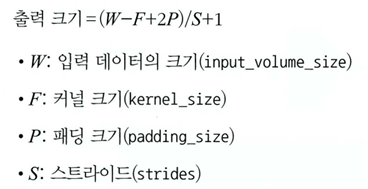

> nn.Conv2d(in_channels=1, out_channels= 32, kernel_size=3, padding=1)

> 입력크기 28

> (28-3+ 2*1)/1 +1 = 28

> 출력형태 = [32,28,28]

- MaxPool2d 계층에서 출력크기 구하기
  - IF/F
  - IF: 입력 필터 크기
  - F: 커널 크기

6. 합성곱층-> 완전연결층 : 데이터 1차원으로 바꿔주기
- out.size(0) =100
- out.view(out.size(0), -1)

In [25]:
# 합성곱 네트워크를 위한 파라미터 정의
learning_rate= 0.001;
model= FashionCNN();
model.to(device)

criterion= nn.CrossEntropyLoss();
optimizer= torch.optim.Adam(model.parameters(), lr= learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [26]:
# 모델 학습 및 성능 평가
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels= images.to(device), labels.to(device)

        train= Variable(images.view(100,1,28,28))
        labels= Variable(labels)

        outputs= model(train)
        loss= criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count+=1

        if not (count%50):
            total=0
            correct=0
            for images, labels in test_loader:
                images, labels= images.to(device), labels.to(device)
                labels_list.append(labels)
                test= Variable(images.view(100,1,28,28))
                outputs= model(test)
                predictions= torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct+= (predictions==labels).sum()
                total+= len(labels)

            accuracy= correct*100/total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not(count%500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.4232306182384491, Accuracy: 87.66000366210938%
Iteration: 1000, Loss: 0.3033457100391388, Accuracy: 88.91000366210938%
Iteration: 1500, Loss: 0.3155564069747925, Accuracy: 89.16000366210938%
Iteration: 2000, Loss: 0.15056565403938293, Accuracy: 89.66000366210938%
Iteration: 2500, Loss: 0.15448330342769623, Accuracy: 89.54000091552734%
Iteration: 3000, Loss: 0.17483480274677277, Accuracy: 90.3499984741211%
